# 1.2 — Exploration et statistiques du dataset SH17

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from collections import defaultdict

DATASET_ROOT = Path(r"C:\Users\luigi\OneDrive\Documents\Ecole 18.06\Traitement_image\Projet\SH17dataset")

CLASSES = {
    0: 'person',      1: 'ear',          2: 'ear-mufs',     3: 'face',
    4: 'face-guard',  5: 'face-mask',    6: 'foot',         7: 'tool',
    8: 'glasses',     9: 'gloves',      10: 'helmet',      11: 'hands',
   12: 'head',       13: 'medical-suit',14: 'shoes',       15: 'safety-suit',
   16: 'safety-vest'
}

SPLITS = ['train', 'val', 'test']

PALETTE = [
    (255,  56,  56), (255, 157,  51), (255, 212,  51), (51, 255,  86),
    ( 51, 255, 189), ( 51, 198, 255), ( 51,  69, 255), (162,  51, 255),
    (255,  51, 255), (255,  51, 153), (  0, 200, 200), (200, 100,   0),
    (100, 200,   0), (  0, 100, 200), (200,   0, 100), (128, 128,   0),
    (  0, 128, 128)
]

## 1. Comptage par split

In [2]:
for split in SPLITS:
    n_imgs = len(list((DATASET_ROOT / 'images' / split).glob('*.*')))
    n_lbls = len(list((DATASET_ROOT / 'labels' / split).glob('*.txt')))
    print(f"{split:5s} : {n_imgs:5d} images  /  {n_lbls:5d} labels")

train :  6479 images  /   6479 labels
val   :  1458 images  /   1458 labels
test  :   162 images  /    162 labels


## 2. Distribution des instances par classe

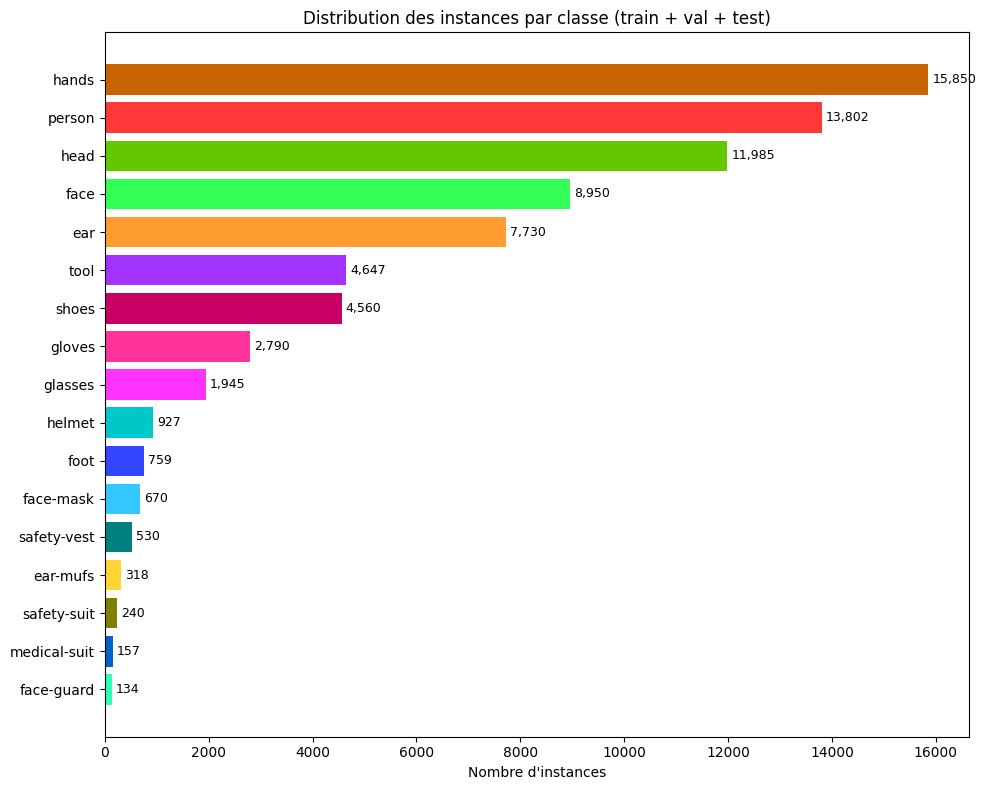

In [3]:
counts = defaultdict(int)
for split in SPLITS:
    for lbl_file in (DATASET_ROOT / 'labels' / split).glob('*.txt'):
        for line in lbl_file.read_text().strip().splitlines():
            if line:
                counts[int(line.split()[0])] += 1

sorted_items = sorted(counts.items(), key=lambda x: x[1], reverse=True)
class_names  = [CLASSES[k] for k, _ in sorted_items]
class_values = [v          for _, v in sorted_items]
bar_colors   = [tuple(c/255 for c in PALETTE[k]) for k, _ in sorted_items]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(class_names, class_values, color=bar_colors)
for bar, val in zip(bars, class_values):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Nombre d\'instances')
ax.set_title('Distribution des instances par classe (train + val + test)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3. Ratio déséquilibre

In [4]:
max_cls = max(counts, key=counts.get)
min_cls = min(counts, key=counts.get)
ratio   = counts[max_cls] / counts[min_cls]

print(f"Classe majoritaire : {CLASSES[max_cls]:<15} {counts[max_cls]:>7,} instances")
print(f"Classe minoritaire : {CLASSES[min_cls]:<15} {counts[min_cls]:>7,} instances")
print(f"Ratio              : {ratio:.1f}x")

Classe majoritaire : hands            15,850 instances
Classe minoritaire : face-guard          134 instances
Ratio              : 118.3x


**Interprétation :** un ratio élevé signifie que le modèle va voir la classe majoritaire beaucoup plus souvent pendant l'entraînement. Cela peut entraîner un biais : le modèle sera plus précis sur les classes fréquentes et moins fiable sur les classes rares. Des stratégies comme le **class weighting** ou le **oversampling** des classes minoritaires peuvent atténuer cet effet.

## 4. Visualisation d'exemples annotés (3 splits)

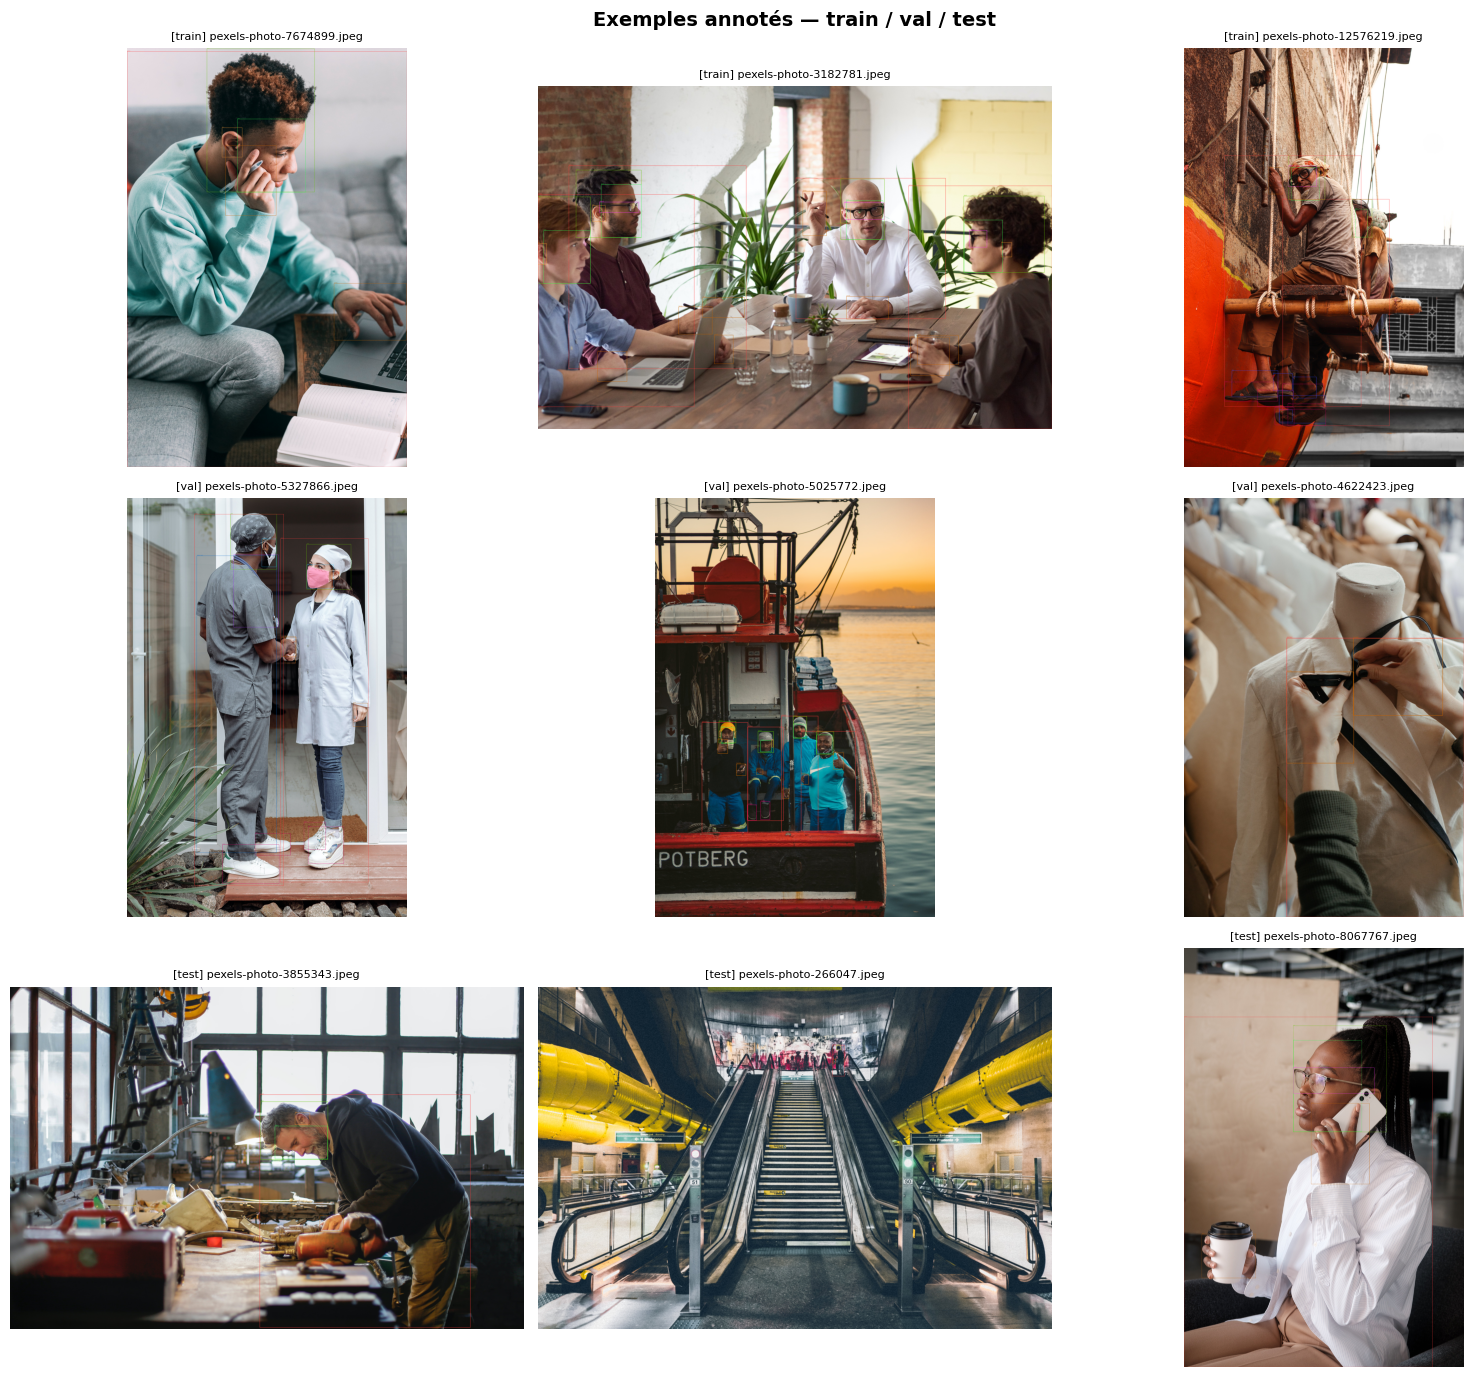

In [5]:
random.seed(42)
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for row, split in enumerate(SPLITS):
    imgs   = list((DATASET_ROOT / 'images' / split).glob('*.*'))
    sample = random.sample(imgs, 3)

    for col, img_path in enumerate(sample):
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        lbl_path = DATASET_ROOT / 'labels' / split / (img_path.stem + '.txt')

        if lbl_path.exists():
            for line in lbl_path.read_text().strip().splitlines():
                if not line:
                    continue
                parts = line.split()
                cls   = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:5])
                x1 = int((xc - bw / 2) * w)
                y1 = int((yc - bh / 2) * h)
                x2 = int((xc + bw / 2) * w)
                y2 = int((yc + bh / 2) * h)
                color = PALETTE[cls]
                cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img, CLASSES[cls], (x1, max(y1 - 5, 12)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        axes[row][col].set_title(f'[{split}] {img_path.name[:28]}', fontsize=8)

plt.suptitle('Exemples annotés — train / val / test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Statistiques sur les tailles des bounding boxes

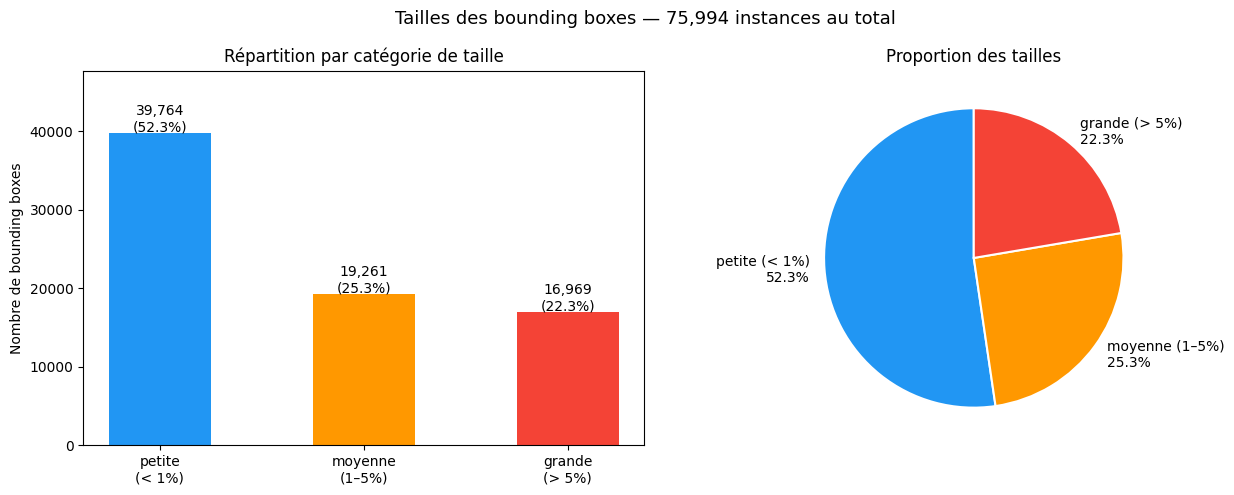

Total bounding boxes : 75,994
  petite (< 1%)        : 39,764  (52.3%)
  moyenne (1–5%)       : 19,261  (25.3%)
  grande (> 5%)        : 16,969  (22.3%)


In [6]:
sizes = {'petite\n(< 1%)': 0, 'moyenne\n(1–5%)': 0, 'grande\n(> 5%)': 0}

for split in SPLITS:
    for lbl_file in (DATASET_ROOT / 'labels' / split).glob('*.txt'):
        for line in lbl_file.read_text().strip().splitlines():
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 5:
                area = float(parts[3]) * float(parts[4])
                if area < 0.01:
                    sizes['petite\n(< 1%)']   += 1
                elif area < 0.05:
                    sizes['moyenne\n(1–5%)']  += 1
                else:
                    sizes['grande\n(> 5%)']   += 1

total  = sum(sizes.values())
colors = ['#2196F3', '#FF9800', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(sizes.keys(), sizes.values(), color=colors, width=0.5)
for bar, val in zip(bars, sizes.values()):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'{val:,}\n({100*val/total:.1f}%)', ha='center', fontsize=10)
axes[0].set_ylabel('Nombre de bounding boxes')
axes[0].set_title('Répartition par catégorie de taille')
axes[0].set_ylim(0, max(sizes.values()) * 1.2)

axes[1].pie(
    sizes.values(),
    labels=[f"{k.replace(chr(10), ' ')}\n{100*v/total:.1f}%" for k, v in sizes.items()],
    colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Proportion des tailles')

plt.suptitle(f'Tailles des bounding boxes — {total:,} instances au total', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total bounding boxes : {total:,}")
for label, val in sizes.items():
    print(f"  {label.replace(chr(10), ' '):20s} : {val:6,}  ({100*val/total:.1f}%)")